C:\Users\ericg\AppData\Local\Temp\ipykernel_17428\1654548345.py:27: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.set_index("time").resample("1S").mean()


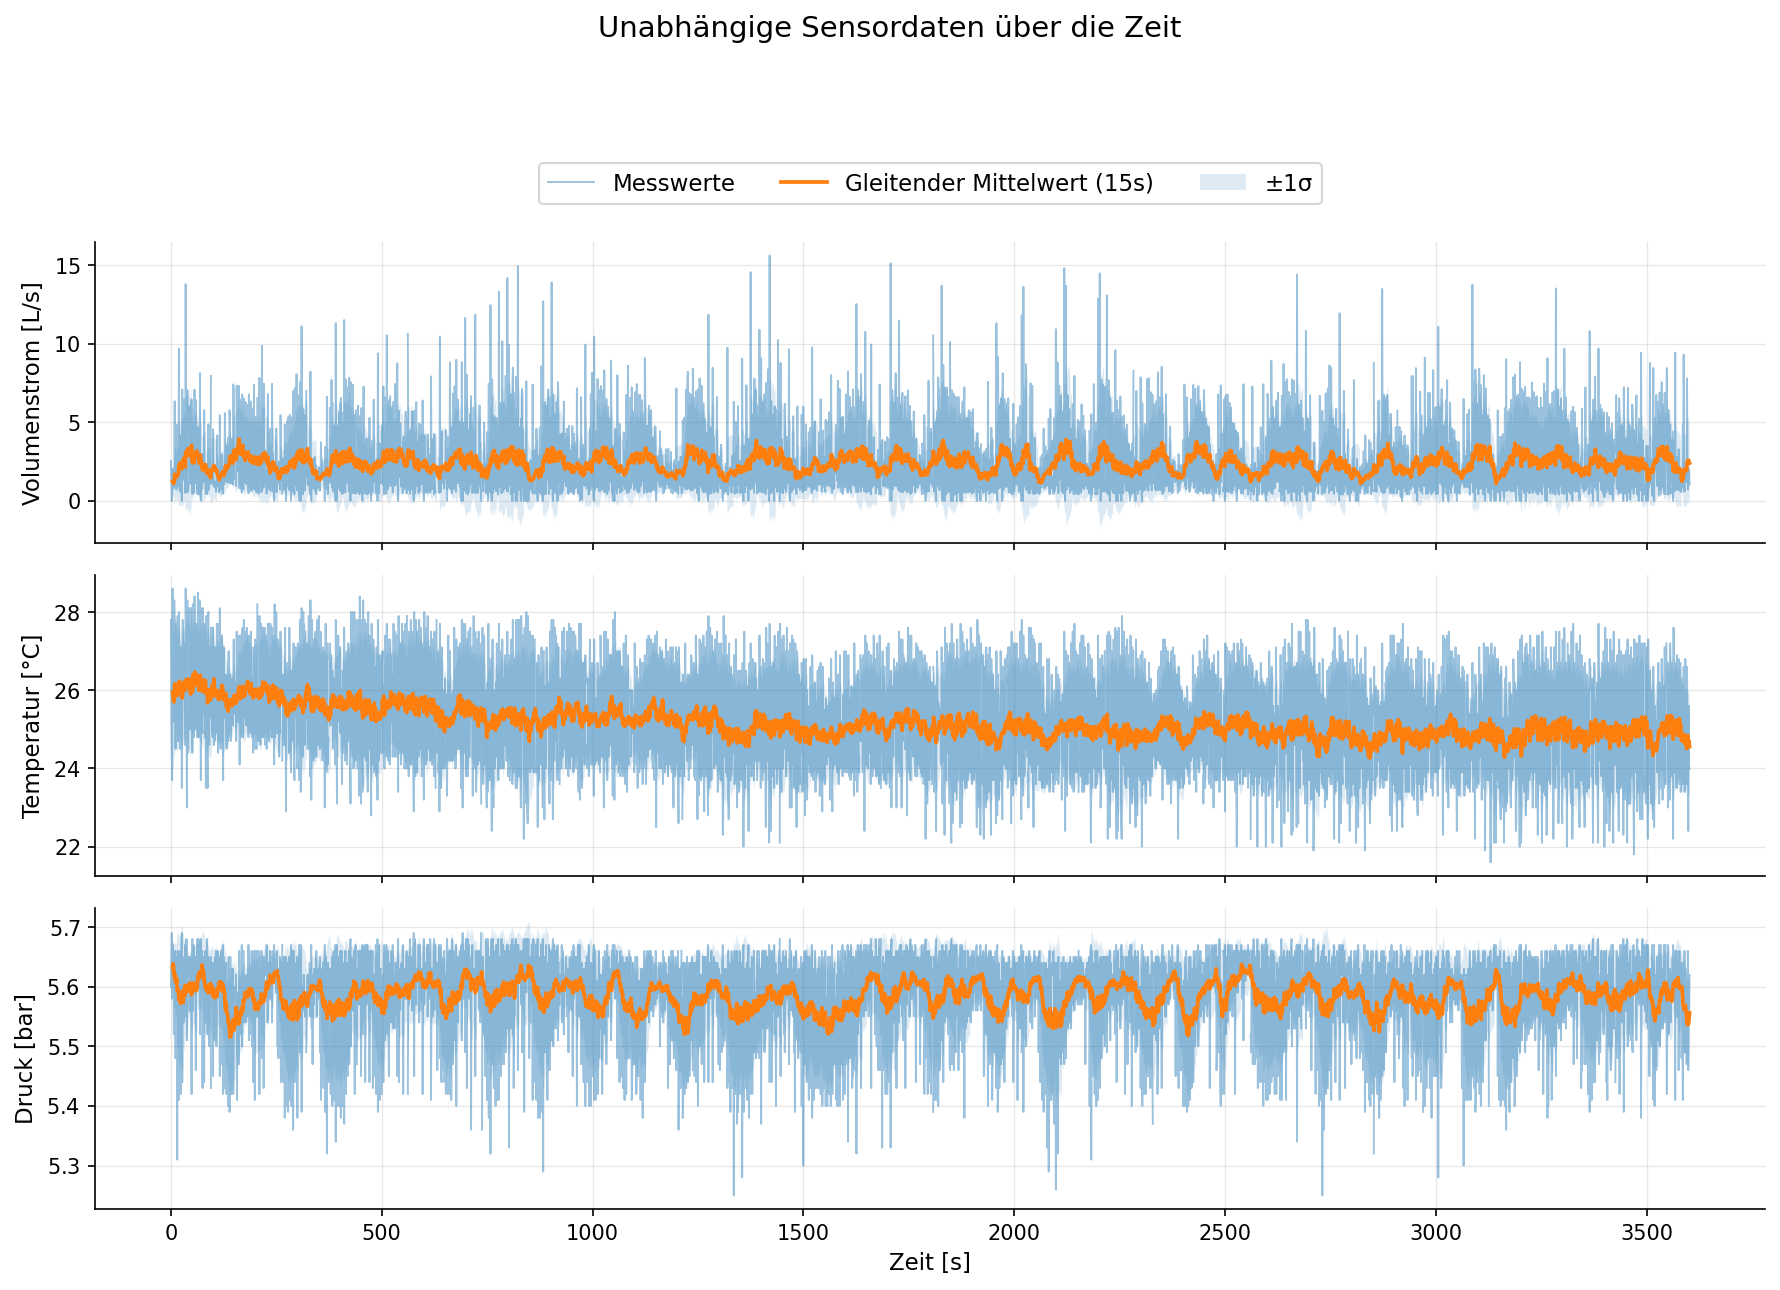

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# -----------------------------
# Daten laden & vorbereiten
# -----------------------------
df = pd.read_csv("mqtt_data_filtered.csv")

column_mapping = {
    "Group4-2_S6_VolumetricFlowRate": "Volumenstrom",
    "Group4-2_S6_Temperature": "Temperatur",
    "Group4-2_S6_Pressure": "Druck",
}

units_mapping = {
    "Volumenstrom": "L/s",
    "Temperatur": "°C",
    "Druck": "bar",
}

cols = list(column_mapping.keys()) + ["time"]
df = df[cols].copy()

# Zeitformat anpassen
df["time"] = pd.to_datetime(df["time"], unit="ms")
df = df.set_index("time").resample("1S").mean()
df["elapsed_time_seconds"] = (df.index - df.index[0]).total_seconds()

# Spalten umbenennen
df = df.rename(columns=column_mapping)
vars_de = list(column_mapping.values())

# Rolling Statistik (optional zur Glättung)
win = 15  # Sekunden
for var in vars_de:
    df[f"{var}__mean"] = df[var].rolling(win, min_periods=max(3, win//3)).mean()
    df[f"{var}__std"] = df[var].rolling(win, min_periods=max(3, win//3)).std()

# -----------------------------
# Plot erstellen
# -----------------------------
plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.6,
})

fig, axes = plt.subplots(
    nrows=len(vars_de),
    ncols=1,
    figsize=(12, 2.8 * len(vars_de)),
    sharex=True
)

for ax, var in zip(axes, vars_de):
    x = df["elapsed_time_seconds"]
    y = df[var]
    y_mean = df[f"{var}__mean"]
    y_std = df[f"{var}__std"]

    # Rohdaten
    ax.plot(x, y, linewidth=0.9, alpha=0.45, label="Messwerte")
    # Gleitender Mittelwert
    ax.plot(x, y_mean, linewidth=1.8, label=f"Gleitender Mittelwert ({win}s)")
    # Unsicherheitsband ±1σ
    ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, label="±1σ")

    ax.set_ylabel(f"{var} [{units_mapping[var]}]")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis="y", style="sci", scilimits=(-3, 3))
    ax.grid(True)

axes[-1].set_xlabel("Zeit [s]")

# Legende nur einmal oben
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, 1.3), ncol=3)

fig.suptitle("Unabhängige Sensordaten über die Zeit", fontsize=14, y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# Speichern
fig.savefig("sensordaten_unabhaengig.png", bbox_inches="tight")
fig.savefig("sensordaten_unabhaengig.pdf", bbox_inches="tight")

plt.show()


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from statsmodels.tsa.stattools import acf, pacf
from sklearn.preprocessing import StandardScaler
from pathlib import Path

# =============================
# Konfiguration
# =============================
CSV = "mqtt_data_filtered.csv"
OUT = Path("feature_analysis_out"); OUT.mkdir(exist_ok=True)

# Ziel & Basissignale (physikalisch unabhängig gewählt)
column_mapping = {
    "Group4-2_S6_VolumetricFlowRate": "Volumenstrom",
    "Group4-2_S6_Temperature": "Temperatur",
    "Group4-2_S6_Pressure": "Druck",
}
target_col   = "Volumenstrom"
feature_cols = ["Temperatur", "Druck"]

# >>> Phase-Features optional einschalten <<<
USE_PHASE_FEATURES = True
# aus deiner Aktor-Tabelle (Sekunden)
PHASE_PERIODS_S = [2, 3, 4, 6, 8, 10, 15, 20]   # kannst du beliebig kürzen/erweitern

# =============================
# Helper
# =============================
def clean_timeframe(df, cols):
    X = df[cols].replace([np.inf, -np.inf], np.nan)
    X = X.interpolate(method="time", limit_direction="both").ffill().bfill()
    # Falls trotz allem noch NaN vorhanden, härter droppen
    if X.isna().any().any():
        X = X.dropna()
    return X

def safe_acf(series, lags):
    lags_eff = max(1, min(lags, len(series) - 2))
    return acf(series, nlags=lags_eff, fft=True, missing="drop")

def safe_pacf(series, lags, method="ywmle"):
    lags_eff = max(1, min(lags, len(series) - 2))
    try:
        return pacf(series, nlags=lags_eff, method=method)
    except Exception:
        return pacf(series, nlags=lags_eff, method="burg")

def safe_stem(ax, x, y):
    m = np.isfinite(y)
    return ax.stem(np.asarray(x)[m], np.asarray(y)[m])

def add_phase_features(df, periods_s, elapsed_col="elapsed_s"):
    """Erzeugt sin/cos-Phase je Periode (phaseninvariant zum Startzeitpunkt)."""
    if elapsed_col not in df.columns:
        raise ValueError(f"'{elapsed_col}' fehlt.")
    for P in periods_s:
        phi = 2*np.pi*((df[elapsed_col] % P)/P)
        df[f"sin_{P}s"] = np.sin(phi)
        df[f"cos_{P}s"] = np.cos(phi)
    return df

# =============================
# 1) Laden & resamplen
# =============================
raw = pd.read_csv(CSV)
keep = list(column_mapping.keys()) + ["time"]
df = raw[keep].copy()
df["time"] = pd.to_datetime(df["time"], unit="ms")
df = df.set_index("time").resample("1S").mean()
df = df.rename(columns=column_mapping).sort_index()

# Relative Zeit für Phase-Features
df["elapsed_s"] = (df.index - df.index[0]).total_seconds()

# =============================
# 2) Auswahl & Cleaning
# =============================
df = df[feature_cols + [target_col] + ["elapsed_s"]]
df_vals = clean_timeframe(df, feature_cols + [target_col])  # nur Werte

# elapsed_s separat wieder mergen (nicht standardisieren!)
df_clean = df_vals.join(df["elapsed_s"], how="inner")

# =============================
# 3) Optionale Phase-Features
# =============================
extra_phase_cols = []
if USE_PHASE_FEATURES:
    df_clean = add_phase_features(df_clean, PHASE_PERIODS_S, elapsed_col="elapsed_s")
    extra_phase_cols = [f"sin_{p}s" for p in PHASE_PERIODS_S] + [f"cos_{p}s" for p in PHASE_PERIODS_S]

# =============================
# 4) Standardisieren (nur numerische Eingaben, NICHT elapsed_s)
# =============================
scaler_cols = feature_cols + [target_col] + extra_phase_cols
scaler = StandardScaler()
df_clean[scaler_cols] = scaler.fit_transform(df_clean[scaler_cols])

# =============================
# 5) Korrelationsmatrix (Heatmap)
# =============================
corr_cols = [target_col] + feature_cols + extra_phase_cols
corr = df_clean[corr_cols].corr(method="pearson")
corr.to_csv(OUT / "correlation_matrix.csv")

fig, ax = plt.subplots(figsize=(1.2*len(corr_cols), 1.0*len(corr_cols)), constrained_layout=True)
im = ax.imshow(corr.values, vmin=-1, vmax=1, aspect="auto")
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

ax.set_xticks(np.arange(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=60, ha="right")
ax.set_yticks(np.arange(len(corr_cols)))
ax.set_yticklabels(corr_cols)
ax.set_title("Korrelationsmatrix (Pearson)")

fig.savefig(OUT / "correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.close(fig)

# =============================
# 6) MI & mRMR (inkl. Phase-Features, falls aktiv)
# =============================
X_cols = feature_cols + extra_phase_cols
X = df_clean[X_cols].values
y = df_clean[target_col].values

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X_cols).sort_values(ascending=False)
mi_series.to_csv(OUT / "mi_results_including_phase.csv", header=["MI"])

def mrmr_selection(X, y, k):
    selected, remaining = [], list(range(X.shape[1]))
    base_mi = mutual_info_regression(X, y, random_state=42)
    # 1) höchste Relevanz zuerst
    first = int(np.argmax(base_mi)); selected.append(first); remaining.remove(first)
    # 2) sukzessive max (Relevanz - Redundanz)
    for _ in range(k - 1):
        scores = []
        for feat in remaining:
            rel = base_mi[feat]
            reds = [mutual_info_regression(X[:, [feat]], X[:, [s]], random_state=42)[0] for s in selected]
            red = float(np.mean(reds)) if len(reds) else 0.0
            scores.append(rel - red)
        best = remaining[int(np.argmax(scores))]
        selected.append(best); remaining.remove(best)
    return selected

mrmr_idx = mrmr_selection(X, y, k=min(10, X.shape[1]))  # top 10 für Übersicht
mrmr_ranked = pd.Series(range(1, len(mrmr_idx)+1), index=[X_cols[i] for i in mrmr_idx], name="rank")
mrmr_ranked.to_csv(OUT / "mrmr_ranking_including_phase.csv", header=["rank"])

# =============================
# 7) CCF, ACF, PACF (wie zuvor)
# =============================
def cross_corr(a, b, lag_max):
    out = []
    for lag in range(0, lag_max + 1):
        aa, bb = (a, b) if lag == 0 else (a[:-lag], b[lag:])
        if len(aa) < 3: out.append(np.nan); continue
        out.append(np.corrcoef(aa, bb)[0, 1])
    return np.asarray(out, dtype=float)

lag_max = 30
ccf_results = {feat: cross_corr(df_clean[feat].values, df_clean[target_col].values, lag_max)
               for feat in feature_cols}  # CCF für physikalische Features

lags_wish = 30
acf_results = {}
pacf_results = {}
for col in feature_cols + [target_col]:
    s = pd.Series(df_clean[col].values).dropna()
    acf_results[col]  = safe_acf(s, lags_wish)
    pacf_results[col] = safe_pacf(s, lags_wish, method="ywmle")

# =============================
# 8) Plot-Übersicht (inkl. Korrelations-Heatmap separat schon gespeichert)
# =============================
plt.rcParams.update({
    "figure.dpi": 150, "savefig.dpi": 300,
    "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "axes.grid": True, "grid.alpha": 0.3, "grid.linewidth": 0.6,
})

fig, axes = plt.subplots(3, 2, figsize=(13, 10))

# MI (Top 10)
mi_plot = mi_series.head(10)
axes[0,0].bar(mi_plot.index, mi_plot.values)
axes[0,0].set_title("Mutual Information zum Ziel (Top 10)")
axes[0,0].set_ylabel("MI")
axes[0,0].tick_params(axis='x', rotation=60)

# mRMR (Top 10)
mrmr_plot = mrmr_ranked.index[:10]
axes[0,1].bar(range(len(mrmr_plot)), [mi_series[f] for f in mrmr_plot])
axes[0,1].set_xticks(range(len(mrmr_plot)))
axes[0,1].set_xticklabels(mrmr_plot, rotation=60)
axes[0,1].set_title("mRMR Ranking (Top 10)")

# CCF (Temperatur, Druck)
for i, feat in enumerate(feature_cols):
    x = np.arange(lag_max + 1)
    y = ccf_results[feat]
    safe_stem(axes[1, i], x, y)
    axes[1, i].set_title(f"CCF: {feat} → {target_col}")
    axes[1, i].set_xlabel("Lag (s)")
    axes[1, i].set_ylabel("Korrelation")

# ACF/PACF (Ziel)
lags_acf  = len(acf_results[target_col]) - 1
lags_pacf = len(pacf_results[target_col]) - 1
safe_stem(axes[2,0], np.arange(lags_acf + 1),  acf_results[target_col])
axes[2,0].set_title(f"ACF: {target_col}")
axes[2,0].set_xlabel("Lag (s)")
safe_stem(axes[2,1], np.arange(lags_pacf + 1), pacf_results[target_col])
axes[2,1].set_title(f"PACF: {target_col}")
axes[2,1].set_xlabel("Lag (s)")

# Konfidenzbänder ACF/PACF
N = len(df_clean)
conf = 1.96 / np.sqrt(max(N, 1))
for ax in (axes[2,0], axes[2,1]):
    ax.axhline(+conf, color="gray", linestyle="--", linewidth=1, alpha=0.6)
    ax.axhline(-conf, color="gray", linestyle="--", linewidth=1, alpha=0.6)

fig.suptitle("Feature-Analyse (mit optionalen Phase-Features)", y=1.02)
plt.tight_layout(rect=[0,0,1,0.98])
plt.savefig(OUT / "feature_analysis_overview.png", dpi=300, bbox_inches="tight")
plt.close()

# =============================
# 9) Logs
# =============================
print(f"Korrelationsmatrix: {OUT/'correlation_matrix.png'}")
print(f"MI (inkl. Phase):   {OUT/'mi_results_including_phase.csv'}")
print(f"mRMR (inkl. Phase): {OUT/'mrmr_ranking_including_phase.csv'}")
print(f"Plots/CSVs im Ordner: {OUT.resolve()}")


C:\Users\ericg\AppData\Local\Temp\ipykernel_20872\1372280571.py:72: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.set_index("time").resample("1S").mean()
c:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\.venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\.venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\.venv\lib\site-packages\sklearn\utils\validation.py:1406

Korrelationsmatrix: feature_analysis_out\correlation_matrix.png
MI (inkl. Phase):   feature_analysis_out\mi_results_including_phase.csv
mRMR (inkl. Phase): feature_analysis_out\mrmr_ranking_including_phase.csv
Plots/CSVs im Ordner: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Read_WanDa_data\feature_analysis_out


Vergleichstabelle gespeichert: feature_analysis_out\feature_vs_target_dependency.csv


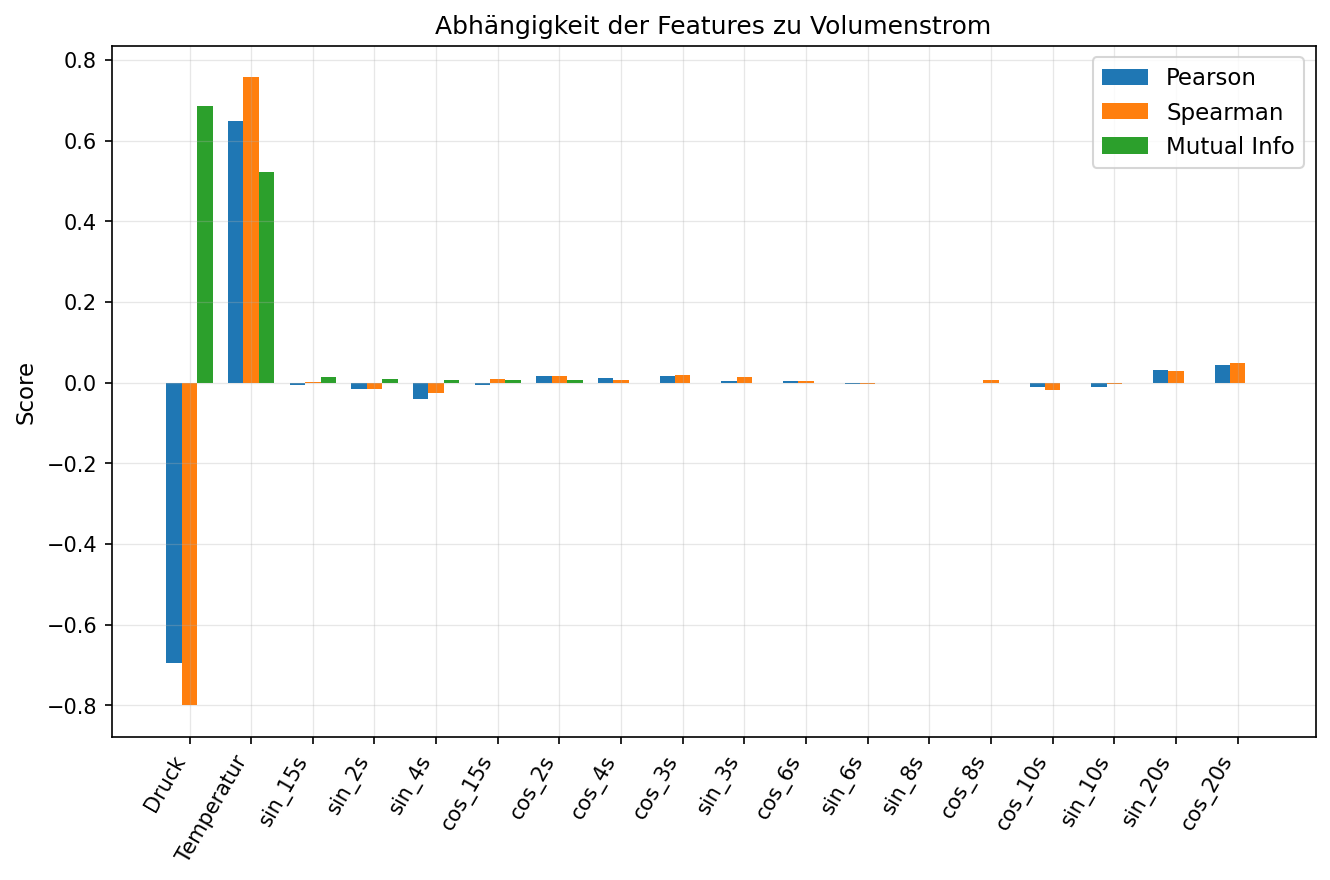

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr

# =============================
# Annahme: df_clean aus deinem bisherigen Code existiert
# =============================

# Ziel- und Featureliste
target = "Volumenstrom"
all_features = [c for c in df_clean.columns if c != target and c != "elapsed_s"]

# -----------------------------
# 1) Pearson-Korrelation
# -----------------------------
pearson_vals = df_clean[all_features].corrwith(df_clean[target], method="pearson")

# -----------------------------
# 2) Spearman-Korrelation
# -----------------------------
spearman_vals = pd.Series(
    {feat: spearmanr(df_clean[feat], df_clean[target])[0] for feat in all_features}
)

# -----------------------------
# 3) Mutual Information
# -----------------------------
X = df_clean[all_features].values
y = df_clean[target].values
mi_vals = pd.Series(mutual_info_regression(X, y, random_state=42), index=all_features)

# -----------------------------
# 4) Tabelle zusammenbauen
# -----------------------------
df_compare = pd.DataFrame({
    "Pearson": pearson_vals,
    "Spearman": spearman_vals,
    "Mutual_Info": mi_vals
}).sort_values("Mutual_Info", ascending=False)

# Speichern
OUT_PATH = OUT / "feature_vs_target_dependency.csv"
df_compare.to_csv(OUT_PATH)
print(f"Vergleichstabelle gespeichert: {OUT_PATH}")

# -----------------------------
# 5) Plot: alle drei Metriken nebeneinander
# -----------------------------
fig, ax = plt.subplots(figsize=(0.5*len(df_compare), 6))

x = np.arange(len(df_compare))
width = 0.25

ax.bar(x - width, df_compare["Pearson"], width, label="Pearson")
ax.bar(x,         df_compare["Spearman"], width, label="Spearman")
ax.bar(x + width, df_compare["Mutual_Info"], width, label="Mutual Info")

ax.set_xticks(x)
ax.set_xticklabels(df_compare.index, rotation=60, ha="right")
ax.set_ylabel("Score")
ax.set_title(f"Abhängigkeit der Features zu {target}")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(OUT / "feature_dependency_comparison.png", dpi=300)
plt.show()


Vergleichstabelle gespeichert: feature_analysis_out\feature_vs_target_dependency_with_mrmr.csv


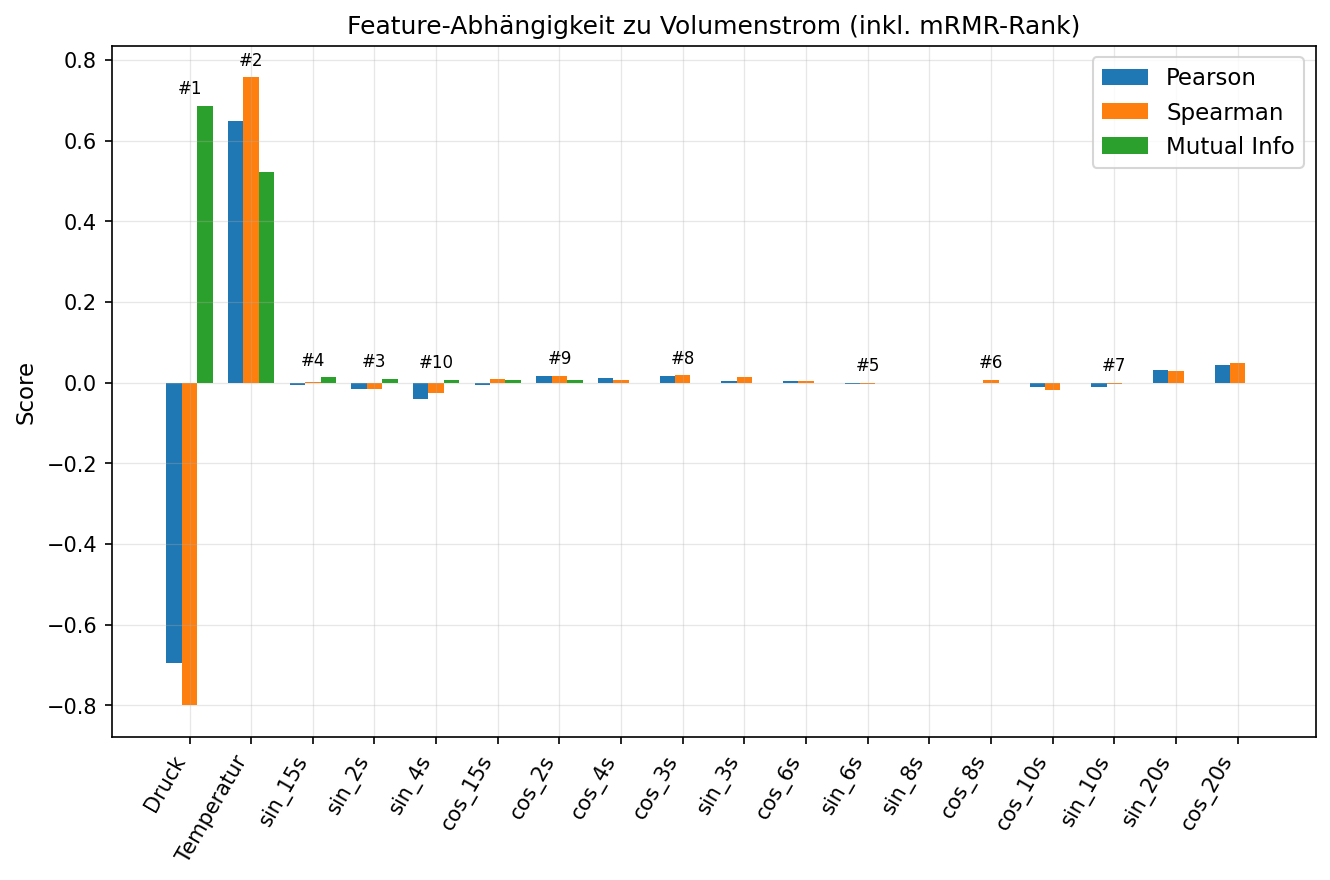

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr

# Annahme: df_clean, target_col, OUT, mrmr_ranked aus vorheriger Analyse vorhanden
target = target_col
all_features = [c for c in df_clean.columns if c != target and c != "elapsed_s"]

# -----------------------------
# 1) Pearson-Korrelation
# -----------------------------
pearson_vals = df_clean[all_features].corrwith(df_clean[target], method="pearson")

# -----------------------------
# 2) Spearman-Korrelation
# -----------------------------
spearman_vals = pd.Series(
    {feat: spearmanr(df_clean[feat], df_clean[target])[0] for feat in all_features}
)

# -----------------------------
# 3) Mutual Information
# -----------------------------
X = df_clean[all_features].values
y = df_clean[target].values
mi_vals = pd.Series(mutual_info_regression(X, y, random_state=42), index=all_features)

# -----------------------------
# 4) mRMR-Rankings hinzufügen
# -----------------------------
mrmr_rank_dict = mrmr_ranked.to_dict()  # {"Feature": rank}
mrmr_ranks = pd.Series({feat: mrmr_rank_dict.get(feat, np.nan) for feat in all_features})

# -----------------------------
# 5) Vergleichstabelle erstellen
# -----------------------------
df_compare = pd.DataFrame({
    "Pearson": pearson_vals,
    "Spearman": spearman_vals,
    "Mutual_Info": mi_vals,
    "mRMR_Rank": mrmr_ranks
}).sort_values("Mutual_Info", ascending=False)

# Speichern
OUT_PATH = OUT / "feature_vs_target_dependency_with_mrmr.csv"
df_compare.to_csv(OUT_PATH)
print(f"Vergleichstabelle gespeichert: {OUT_PATH}")

# -----------------------------
# 6) Plot mit allen drei Scores
# -----------------------------
fig, ax = plt.subplots(figsize=(0.5*len(df_compare), 6))

x = np.arange(len(df_compare))
width = 0.25

ax.bar(x - width, df_compare["Pearson"], width, label="Pearson")
ax.bar(x,         df_compare["Spearman"], width, label="Spearman")
ax.bar(x + width, df_compare["Mutual_Info"], width, label="Mutual Info")

# mRMR-Rank als Text oberhalb der Balkenmitte
for i, rank in enumerate(df_compare["mRMR_Rank"]):
    if not np.isnan(rank):
        ax.text(i, max(df_compare.iloc[i, :3]) + 0.02, f"#{int(rank)}",
                ha="center", va="bottom", fontsize=8, rotation=0)

ax.set_xticks(x)
ax.set_xticklabels(df_compare.index, rotation=60, ha="right")
ax.set_ylabel("Score")
ax.set_title(f"Feature-Abhängigkeit zu {target} (inkl. mRMR-Rank)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(OUT / "feature_dependency_with_mrmr.png", dpi=300)
plt.show()



Top-10 Features für Modelltraining gespeichert: feature_analysis_out\top_10_features.csv
             Pearson  Spearman  Mutual_Info  mRMR_Rank
Druck      -0.696251 -0.799869     0.686774        1.0
Temperatur  0.647840  0.756805     0.523182        2.0
sin_2s     -0.015785 -0.016439     0.009837        3.0
sin_15s    -0.004740  0.000762     0.013163        4.0
sin_6s     -0.002630 -0.004110     0.000000        5.0
cos_8s     -0.000040  0.006861     0.000000        6.0
sin_10s    -0.010844 -0.002560     0.000000        7.0
cos_3s      0.016751  0.018202     0.000000        8.0
cos_2s      0.015785  0.016439     0.006088        9.0
sin_4s     -0.040904 -0.026070     0.006426       10.0


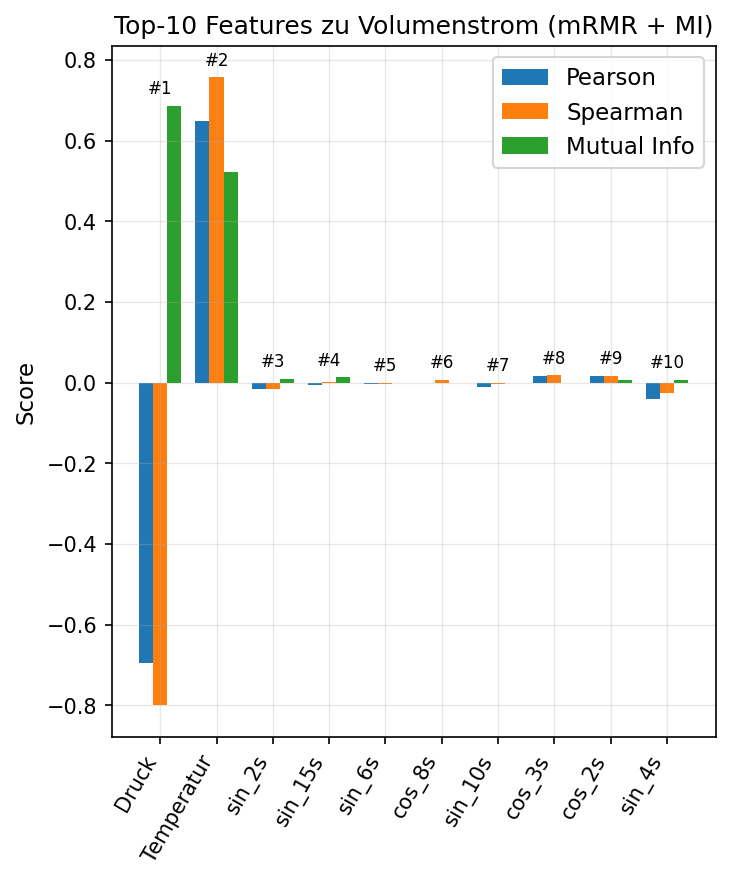

In [6]:
# =============================
# 7) Top-N Feature-Auswahl
# =============================
TOP_N = 10  # <-- kannst du anpassen

# Zuerst nur Features mit mRMR-Rank sortieren
ranked_features = df_compare.dropna(subset=["mRMR_Rank"]).sort_values("mRMR_Rank").index.tolist()

# Falls weniger als N vorhanden -> mit MI auffüllen
if len(ranked_features) < TOP_N:
    # Features ohne Rank, nach MI sortieren
    remaining = [f for f in df_compare.index if f not in ranked_features]
    remaining_sorted = df_compare.loc[remaining].sort_values("Mutual_Info", ascending=False).index.tolist()
    ranked_features.extend(remaining_sorted[:TOP_N - len(ranked_features)])

# Nur die ersten N behalten
top_features = ranked_features[:TOP_N]

# Tabelle der Top-N Features
df_top = df_compare.loc[top_features]
OUT_TOP_PATH = OUT / f"top_{TOP_N}_features.csv"
df_top.to_csv(OUT_TOP_PATH)

print(f"\nTop-{TOP_N} Features für Modelltraining gespeichert: {OUT_TOP_PATH}")
print(df_top)

# -----------------------------
# Optional: Visualisierung der Top-N Features
# -----------------------------
fig, ax = plt.subplots(figsize=(0.5*len(df_top), 6))

x = np.arange(len(df_top))
width = 0.25

ax.bar(x - width, df_top["Pearson"], width, label="Pearson")
ax.bar(x,         df_top["Spearman"], width, label="Spearman")
ax.bar(x + width, df_top["Mutual_Info"], width, label="Mutual Info")

# mRMR-Rank als Text
for i, rank in enumerate(df_top["mRMR_Rank"]):
    if not np.isnan(rank):
        ax.text(i, max(df_top.iloc[i, :3]) + 0.02, f"#{int(rank)}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(df_top.index, rotation=60, ha="right")
ax.set_ylabel("Score")
ax.set_title(f"Top-{TOP_N} Features zu {target} (mRMR + MI)")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.savefig(OUT / f"top_{TOP_N}_features_plot.png", dpi=300)
plt.show()


C:\Users\ericg\AppData\Local\Temp\ipykernel_17428\2818881720.py:47: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.set_index("time").resample("1S").mean()


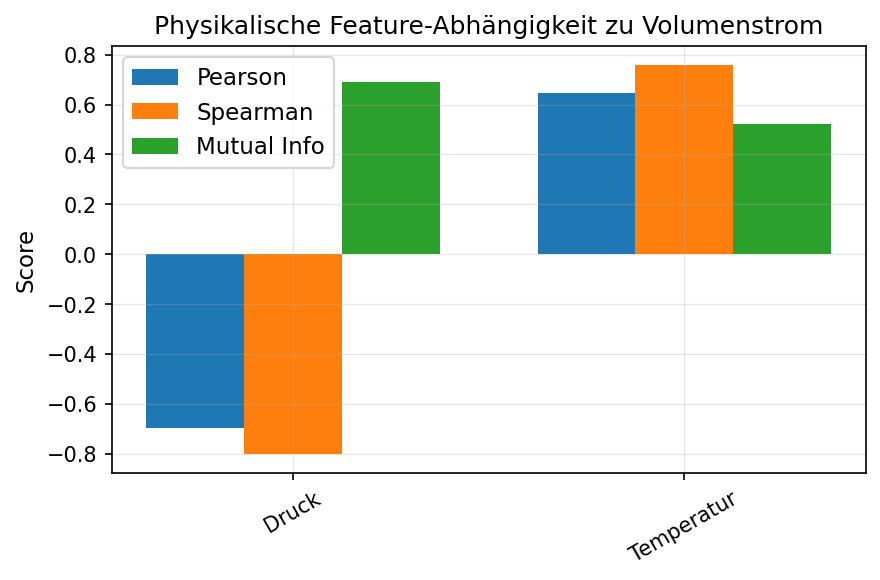

In [6]:
# feature_analysis_physical.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import spearmanr
from pathlib import Path

# -------------------------
# Konfiguration
# -------------------------
CSV = "mqtt_data_filtered.csv"
OUT = Path("feature_analysis_physical_out"); OUT.mkdir(exist_ok=True)

# Mapping
column_mapping = {
    "Group4-2_S6_VolumetricFlowRate": "Volumenstrom",  # L/s
    "Group4-2_S6_Temperature": "Temperatur",          # °C
    "Group4-2_S6_Pressure": "Druck"                   # bar(g)
}
target_col = "Volumenstrom"
feature_cols = ["Temperatur", "Druck"]

# -------------------------
# Daten laden & vorbereiten
# -------------------------
# Nach dem Einlesen & Umbenennen, bevor du resamplest:
df = pd.read_csv("mqtt_data_filtered.csv")
df["time"] = pd.to_datetime(df["time"], unit="ms")
df = df.rename(columns=column_mapping)

# Nur die Spalten behalten, die du brauchst:
keep = list(column_mapping.values()) + ["time"]  # z.B. ["Volumenstrom","Temperatur","Druck","time"]
df = df[keep].copy()

# HARTE NUMERIC-CASTS (verhindert object-Dtypes in mean):
value_cols = [c for c in df.columns if c != "time"]

# optional: Komma-zu-Punkt, falls irgendwo Dezimalkommas drin sind
for c in value_cols:
    if df[c].dtype == "object":
        df[c] = df[c].astype(str).str.replace(",", ".", regex=False)

df[value_cols] = df[value_cols].apply(pd.to_numeric, errors="coerce")

# jetzt resamplen – es gibt nur noch numerische Spalten
df = df.set_index("time").resample("1S").mean()

# anschließend fehlende Werte füllen / löschen
df = df.interpolate(method="time").ffill().bfill()

# Standardisieren
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df[feature_cols + [target_col]] = scaler.fit_transform(df[feature_cols + [target_col]])

# -------------------------
# MI, Pearson, Spearman
# -------------------------
pearson_vals = df[feature_cols].corrwith(df[target_col], method="pearson")
spearman_vals = pd.Series({f: spearmanr(df[f], df[target_col])[0] for f in feature_cols})
mi_vals = pd.Series(mutual_info_regression(df[feature_cols].values, df[target_col].values, random_state=42),
                    index=feature_cols)

df_compare = pd.DataFrame({
    "Pearson": pearson_vals,
    "Spearman": spearman_vals,
    "Mutual_Info": mi_vals
}).sort_values("Mutual_Info", ascending=False)

df_compare.to_csv(OUT / "physical_features_dependency.csv")

# -------------------------
# Plot
# -------------------------
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(df_compare))
width = 0.25
ax.bar(x - width, df_compare["Pearson"], width, label="Pearson")
ax.bar(x,         df_compare["Spearman"], width, label="Spearman")
ax.bar(x + width, df_compare["Mutual_Info"], width, label="Mutual Info")
ax.set_xticks(x)
ax.set_xticklabels(df_compare.index, rotation=30)
ax.set_ylabel("Score")
ax.set_title(f"Physikalische Feature-Abhängigkeit zu {target_col}")
ax.grid(True, axis="y", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(OUT / "physical_feature_dependency.png", dpi=300)
plt.show()


C:\Users\ericg\AppData\Local\Temp\ipykernel_17428\812210781.py:45: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.set_index("time").resample("1S").mean()
C:\Users\ericg\AppData\Local\Temp\ipykernel_17428\812210781.py:97: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(top.index, rotation=60, ha="right")


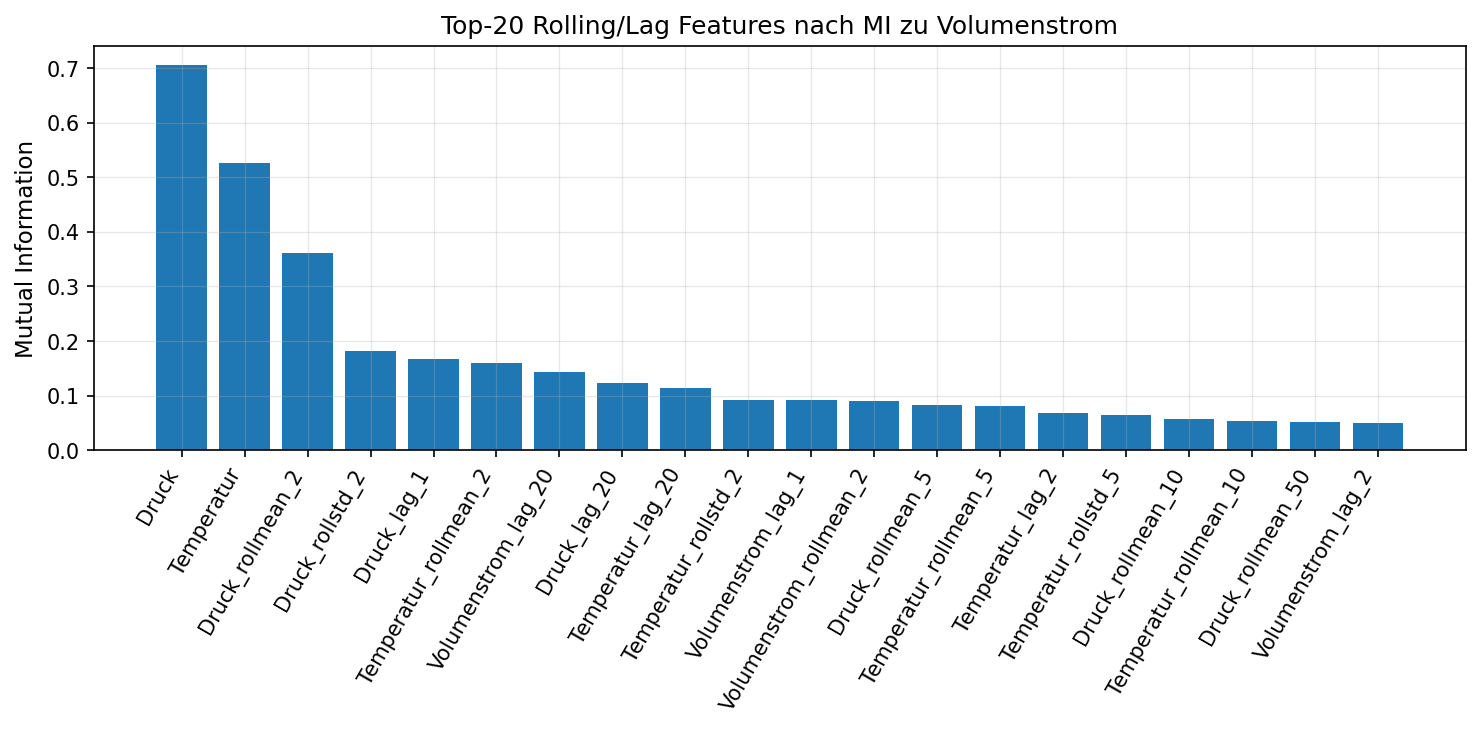

✔ MI-Tabelle: feature_analysis_rolling_lags_out\rolling_lag_features_mi.csv
✔ Plot:       feature_analysis_rolling_lags_out\rolling_lag_feature_mi.png


In [9]:
# feature_analysis_rolling_lags.py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
from pathlib import Path

# -------------------------
# Konfiguration
# -------------------------
CSV = "mqtt_data_filtered.csv"
OUT = Path("feature_analysis_rolling_lags_out"); OUT.mkdir(exist_ok=True)

column_mapping = {
    "Group4-2_S6_VolumetricFlowRate": "Volumenstrom",  # L/s
    "Group4-2_S6_Temperature": "Temperatur",          # °C
    "Group4-2_S6_Pressure": "Druck"                   # bar(g)
}
target_col = "Volumenstrom"
base_features = ["Temperatur", "Druck"]

ROLL_WINDOWS = [2, 5, 10, 20, 50]  # Sekunden
LAGS = [1, 2, 5, 10, 20, 50]        # Sekunden

INCLUDE_Q_LAGS = True           # Lags von Volumenstrom einbeziehen
INCLUDE_Q_ROLLING = True        # Rolling-Stats von Volumenstrom (leak-frei) einbeziehen

# -------------------------
# Daten laden & vorbereiten
# -------------------------
df = pd.read_csv(CSV)
df["time"] = pd.to_datetime(df["time"], unit="ms")
df = df.rename(columns=column_mapping)

keep = list(column_mapping.values()) + ["time"]
df = df[keep].copy()

# Harter Numeric-Cast
for c in [col for col in df.columns if c != "time"]:
    if df[c].dtype == "object":
        df[c] = df[c].astype(str).str.replace(",", ".", regex=False)
df[[c for c in df.columns if c != "time"]] = df[[c for c in df.columns if c != "time"]].apply(pd.to_numeric, errors="coerce")

# Resampling
df = df.set_index("time").resample("1S").mean()
df = df.interpolate(method="time").ffill().bfill()

# -------------------------
# Rolling Mean & Std (Temperatur/Druck)
# -------------------------
for w in ROLL_WINDOWS:
    for f in base_features:
        df[f"{f}_rollmean_{w}"] = df[f].rolling(window=w, min_periods=1).mean()
        df[f"{f}_rollstd_{w}"]  = df[f].rolling(window=w, min_periods=1).std()

# -------------------------
# Lags (Temperatur/Druck)
# -------------------------
for lag in LAGS:
    for f in base_features:
        df[f"{f}_lag_{lag}"] = df[f].shift(lag)

# -------------------------
# Lags & Rolling von Volumenstrom (leak-frei)
# -------------------------
if INCLUDE_Q_LAGS:
    for lag in LAGS:
        df[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)

if INCLUDE_Q_ROLLING:
    for w in ROLL_WINDOWS:
        # Rolling-Fenster nur über Vergangenheit: erst shift(1), dann rolling
        df[f"{target_col}_rollmean_{w}"] = df[target_col].shift(1).rolling(window=w, min_periods=1).mean()
        df[f"{target_col}_rollstd_{w}"]  = df[target_col].shift(1).rolling(window=w, min_periods=1).std()

# NaNs durch Shift/ Rolling entfernen
df = df.dropna()

# -------------------------
# MI mit Ziel
# -------------------------
X_cols = [c for c in df.columns if c != target_col]  # Ziel selbst nicht als Feature
X = df[X_cols].values
y = df[target_col].values

mi = mutual_info_regression(X, y, random_state=42)
mi_vals = pd.Series(mi, index=X_cols).sort_values(ascending=False)
mi_vals.to_csv(OUT / "rolling_lag_features_mi.csv")

# -------------------------
# Plot Top-20
# -------------------------
topN = 20
top = mi_vals.head(topN)
fig, ax = plt.subplots(figsize=(max(8, 0.5*topN), 5))
ax.bar(top.index, top.values)
ax.set_xticklabels(top.index, rotation=60, ha="right")
ax.set_ylabel("Mutual Information")
ax.set_title(f"Top-{topN} Rolling/Lag Features nach MI zu {target_col}")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "rolling_lag_feature_mi.png", dpi=300)
plt.show()

print(f"✔ MI-Tabelle: {OUT/'rolling_lag_features_mi.csv'}")
print(f"✔ Plot:       {OUT/'rolling_lag_feature_mi.png'}")


In [10]:
# feature_analysis_model_based.py
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error

from statsmodels.tsa.stattools import acf, pacf

# -----------------------------
# Konfiguration
# -----------------------------
CSV = "mqtt_data_filtered.csv"
OUT = Path("feature_analysis_model_based_out"); OUT.mkdir(exist_ok=True)

column_mapping = {
    "Group4-2_S6_VolumetricFlowRate": "Volumenstrom",  # L/s
    "Group4-2_S6_Temperature": "Temperatur",          # °C
    "Group4-2_S6_Pressure": "Druck"                   # bar (g oder abs - egal für Analyse)
}

target_col = "Volumenstrom"
base_features = ["Temperatur", "Druck"]           # physikalische Eingaben

# Lags/Windows Kandidaten (Sekunden, bei 1 Hz)
MAX_LAG_SUGGEST = 30
ROLL_WINDOWS = [5, 10, 20]
CANDIDATE_LAGS = [1, 2, 5, 10, 20]               # werden nach ACF/CCF noch gefiltert

RANDOM_STATE = 42

# -----------------------------
# Utilities
# -----------------------------
def hard_numeric_cast(df, time_col="time"):
    val_cols = [c for c in df.columns if c != time_col]
    for c in val_cols:
        if df[c].dtype == "object":
            df[c] = df[c].astype(str).str.replace(",", ".", regex=False)
    df[val_cols] = df[val_cols].apply(pd.to_numeric, errors="coerce")
    return df

def safe_stem(ax, x, y):
    m = np.isfinite(y)
    ax.stem(np.asarray(x)[m], np.asarray(y)[m])

def suggest_ar_lags(series, max_lag):
    """PACF-basierte AR-Lags für die Zielreihe (Volumenstrom).
       Rückgabe: Liste signifikanter Lags (|pacf| > 1.96/sqrt(N))."""
    s = pd.Series(series).dropna()
    N = len(s)
    if N < 10:
        return []
    lags_eff = max(1, min(max_lag, N-2))
    pacf_vals = pacf(s, nlags=lags_eff, method="ywmle")
    conf = 1.96 / np.sqrt(N)
    sig = [lag for lag in range(1, len(pacf_vals)) if abs(pacf_vals[lag]) > conf]
    return sig

def cross_corr(a, b, lag_max):
    out = []
    for lag in range(0, lag_max + 1):
        aa, bb = (a, b) if lag == 0 else (a[:-lag], b[lag:])
        if len(aa) < 3:
            out.append(np.nan); continue
        out.append(np.corrcoef(aa, bb)[0, 1])
    return np.asarray(out, dtype=float)

def suggest_x_lags_to_y(x, y, max_lag, top_k=5):
    """CCF-basiert: wähle Lags von x -> y mit größten |Korrelationen|."""
    c = cross_corr(x, y, max_lag)
    # lag 0 rauslassen (pot. leakage, wir verwenden nur vergangene Werte)
    idx = np.arange(1, len(c))
    vals = np.abs(c[1:])
    order = np.argsort(vals)[::-1]
    chosen = idx[order][:top_k].tolist()
    return chosen

def make_time_split(n, test_ratio=0.2):
    n_test = max(1, int(np.ceil(n * test_ratio)))
    idx_train = np.arange(0, n - n_test)
    idx_test = np.arange(n - n_test, n)
    return idx_train, idx_test

def mrmr_selection(X, y, feat_names, k):
    """Einfaches mRMR: Relevanz (MI zu y) - Redundanz (MI zu bereits gewählten)."""
    mi_to_y = mutual_info_regression(X, y, random_state=RANDOM_STATE)
    selected, remaining = [], list(range(X.shape[1]))
    # 1) Start mit bester Relevanz
    first = int(np.argmax(mi_to_y))
    selected.append(first); remaining.remove(first)
    # 2) sukzessive Auswahl
    while len(selected) < min(k, X.shape[1]):
        scores = []
        for j in remaining:
            rel = mi_to_y[j]
            reds = []
            for s in selected:
                reds.append(mutual_info_regression(X[:, [j]], X[:, [s]], random_state=RANDOM_STATE)[0])
            red = float(np.mean(reds)) if len(reds) else 0.0
            scores.append(rel - red)
        best = remaining[int(np.argmax(scores))]
        selected.append(best); remaining.remove(best)
    return [feat_names[i] for i in selected], mi_to_y

# -----------------------------
# 1) Daten laden & aufbereiten
# -----------------------------
df = pd.read_csv(CSV)
df["time"] = pd.to_datetime(df["time"], unit="ms")
df = df.rename(columns=column_mapping)
keep = ["time", target_col] + base_features
df = df[keep].copy()
df = hard_numeric_cast(df, time_col="time")

# Resample auf 1 Hz, dann Interpolation
df = df.set_index("time").resample("1S").mean()
df = df.interpolate(method="time").ffill().bfill()

# -----------------------------
# 2) Vorschlag relevanter Lags (ACF/PACF/CCF)
# -----------------------------
# AR-Lags für Ziel (Volumenstrom)
ar_lags_q = suggest_ar_lags(df[target_col].values, MAX_LAG_SUGGEST)

# CCF-basiert: Lags von Druck/Temperatur -> Ziel
ccf_lags = {}
for f in base_features:
    cands = suggest_x_lags_to_y(df[f].values, df[target_col].values, MAX_LAG_SUGGEST, top_k=5)
    ccf_lags[f] = cands

# Falls du feste Kandidaten bevorzugst, vereinige mit CANDIDATE_LAGS
# und behalte nur die Schnittmenge mit 1..MAX_LAG_SUGGEST
def clamp_lags(lags):
    return sorted(list({lag for lag in lags if 1 <= lag <= MAX_LAG_SUGGEST}))

ar_lags_q = clamp_lags(ar_lags_q + CANDIDATE_LAGS)
for f in base_features:
    ccf_lags[f] = clamp_lags(ccf_lags[f] + CANDIDATE_LAGS)

# Speichern der Lag-Vorschläge
pd.Series(ar_lags_q, name="lags").to_csv(OUT / "suggested_lags_volumenstrom_pacf.csv", index=False)
pd.DataFrame({f: pd.Series(l) for f, l in ccf_lags.items()}).to_csv(OUT / "suggested_lags_ccf.csv", index=False)

# -----------------------------
# 3) Feature Engineering (leak-frei)
# -----------------------------
Xdf = pd.DataFrame(index=df.index)

# Basis-Features (aktueller Zeitpunkt)
for f in base_features:
    Xdf[f] = df[f]

# Lags der Basis-Features (nur Vergangenheit)
for f in base_features:
    for lag in ccf_lags[f]:
        Xdf[f"{f}_lag_{lag}"] = df[f].shift(lag)

# AR-Lags des Ziels (nur Vergangenheit)
for lag in ar_lags_q:
    Xdf[f"{target_col}_lag_{lag}"] = df[target_col].shift(lag)

# Rolling-Statistiken (leak-frei – Fenster endet vor t)
for w in ROLL_WINDOWS:
    for f in base_features + [target_col]:
        Xdf[f"{f}_rollmean_{w}"] = df[f].shift(1).rolling(window=w, min_periods=1).mean()
        Xdf[f"{f}_rollstd_{w}"]  = df[f].shift(1).rolling(window=w, min_periods=1).std()

# Ziel
y = df[target_col]

# Drop NaNs (durch Shifts/Rollings)
data = pd.concat([Xdf, y], axis=1).dropna()
Xdf = data.drop(columns=[target_col])
y = data[target_col]

# Standardisieren (optional; Tree-Modelle brauchen es nicht, hilft aber bei MI)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(Xdf.values)
feat_names = Xdf.columns.tolist()

# -----------------------------
# 4) mRMR (modellunabhängig)
# -----------------------------
mrmr_feats, mi_to_y = mrmr_selection(X_scaled, y.values, feat_names, k=min(20, X_scaled.shape[1]))
pd.Series(mi_to_y, index=feat_names, name="MI_to_target").to_csv(OUT / "mi_to_target_all.csv")
pd.Series(mrmr_feats, name="mrmr_order").to_csv(OUT / "mrmr_selected_features.csv", index=False)

# Plot Top-20 MI
mi_series = pd.Series(mi_to_y, index=feat_names).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(max(8, 0.5*len(mi_series)), 4.5))
ax.bar(mi_series.index, mi_series.values)
ax.set_xticklabels(mi_series.index, rotation=60, ha="right")
ax.set_ylabel("Mutual Information")
ax.set_title("Top-20 MI zu Volumenstrom")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "mi_top20.png", dpi=300)
plt.close(fig)

# -----------------------------
# 5) Permutation Importance (RandomForest)
# -----------------------------
idx_tr, idx_te = make_time_split(len(y), test_ratio=0.2)
X_tr, X_te = Xdf.values[idx_tr], Xdf.values[idx_te]
y_tr, y_te = y.values[idx_tr], y.values[idx_te]

rf = RandomForestRegressor(
    n_estimators=300, max_depth=12, n_jobs=1, random_state=RANDOM_STATE
)
rf.fit(X_tr, y_tr)
y_pred = rf.predict(X_te)
rf_r2 = r2_score(y_te, y_pred)
rf_mae = mean_absolute_error(y_te, y_pred)

perm = permutation_importance(rf, X_te, y_te, n_repeats=10, random_state=RANDOM_STATE)
perm_series = pd.Series(perm.importances_mean, index=feat_names).sort_values(ascending=False)
perm_series.to_csv(OUT / "permutation_importance_rf.csv")

# Plot
top_perm = perm_series.head(20)
fig, ax = plt.subplots(figsize=(max(8, 0.5*len(top_perm)), 4.5))
ax.bar(top_perm.index, top_perm.values)
ax.set_xticklabels(top_perm.index, rotation=60, ha="right")
ax.set_ylabel("Permutation Importance (mean Δscore)")
ax.set_title(f"RandomForest PI (R2={rf_r2:.3f}, MAE={rf_mae:.3f})")
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(OUT / "rf_permutation_importance_top20.png", dpi=300)
plt.close(fig)

# -----------------------------
# 6) SHAP (XGBoost / LightGBM) – optional
# -----------------------------
def try_xgb_shap(X_tr, y_tr, X_te, feat_names):
    try:
        import xgboost as xgb
        import shap
    except Exception:
        return None, None

    model = xgb.XGBRegressor(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=1,
        tree_method="hist",
    )
    model.fit(X_tr, y_tr)
    expl = shap.TreeExplainer(model)
    # sampling für Geschwindigkeit, falls sehr groß
    X_sample = X_te if len(X_te) <= 5000 else X_te[:5000]
    shap_vals = expl.shap_values(X_sample)
    mean_abs = np.abs(shap_vals).mean(axis=0)
    shap_series = pd.Series(mean_abs, index=feat_names).sort_values(ascending=False)
    shap_series.to_csv(OUT / "shap_xgb_mean_abs.csv")

    # Plot Top-20
    top = shap_series.head(20)
    fig, ax = plt.subplots(figsize=(max(8, 0.5*len(top)), 4.5))
    ax.bar(top.index, top.values)
    ax.set_xticklabels(top.index, rotation=60, ha="right")
    ax.set_ylabel("mean|SHAP|")
    ax.set_title("XGBoost SHAP mean|value| (Top-20)")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT / "shap_xgb_top20.png", dpi=300)
    plt.close(fig)
    return model, shap_series

def try_lgbm_shap(X_tr, y_tr, X_te, feat_names):
    try:
        import lightgbm as lgb
        import shap
    except Exception:
        return None, None

    model = lgb.LGBMRegressor(
        n_estimators=600,
        max_depth=-1,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=RANDOM_STATE,
        n_jobs=1,
    )
    model.fit(X_tr, y_tr)
    expl = shap.TreeExplainer(model)
    X_sample = X_te if len(X_te) <= 5000 else X_te[:5000]
    shap_vals = expl.shap_values(X_sample)
    mean_abs = np.abs(shap_vals).mean(axis=0)
    shap_series = pd.Series(mean_abs, index=feat_names).sort_values(ascending=False)
    shap_series.to_csv(OUT / "shap_lgbm_mean_abs.csv")

    top = shap_series.head(20)
    fig, ax = plt.subplots(figsize=(max(8, 0.5*len(top)), 4.5))
    ax.bar(top.index, top.values)
    ax.set_xticklabels(top.index, rotation=60, ha="right")
    ax.set_ylabel("mean|SHAP|")
    ax.set_title("LightGBM SHAP mean|value| (Top-20)")
    ax.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUT / "shap_lgbm_top20.png", dpi=300)
    plt.close(fig)
    return model, shap_series

xgb_model, shap_xgb = try_xgb_shap(X_tr, y_tr, X_te, feat_names)
lgbm_model, shap_lgbm = try_lgbm_shap(X_tr, y_tr, X_te, feat_names)

# -----------------------------
# 7) Diagnostik: ACF/PACF/CCF Plots speichern (optional, hilfreich)
# -----------------------------
def save_timecorr_plots():
    # ACF/PACF Volumenstrom
    s = pd.Series(df[target_col].values).dropna()
    N = len(s); conf = 1.96 / np.sqrt(max(N,1))
    lags_eff = min(MAX_LAG_SUGGEST, max(2, N-2))
    acf_vals = acf(s, nlags=lags_eff, fft=True, missing="drop")
    pacf_vals = pacf(s, nlags=lags_eff, method="ywmle")

    fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
    safe_stem(axes[0], np.arange(len(acf_vals)), acf_vals); axes[0].set_title("ACF Volumenstrom")
    axes[0].axhline(+conf, linestyle="--"); axes[0].axhline(-conf, linestyle="--")
    safe_stem(axes[1], np.arange(len(pacf_vals)), pacf_vals); axes[1].set_title("PACF Volumenstrom")
    axes[1].axhline(+conf, linestyle="--"); axes[1].axhline(-conf, linestyle="--")
    for ax in axes: ax.grid(True, alpha=0.3); ax.set_xlabel("Lag (s)")
    plt.tight_layout(); plt.savefig(OUT / "acf_pacf_volumenstrom.png", dpi=300); plt.close(fig)

    # CCF Druck/Temperatur -> Volumenstrom
    for f in base_features:
        c = cross_corr(df[f].values, df[target_col].values, MAX_LAG_SUGGEST)
        fig, ax = plt.subplots(figsize=(6, 3.5))
        safe_stem(ax, np.arange(len(c)), c)
        ax.set_title(f"CCF {f} → {target_col}")
        ax.set_xlabel("Lag (s)"); ax.grid(True, alpha=0.3)
        plt.tight_layout(); plt.savefig(OUT / f"ccf_{f}_to_{target_col}.png", dpi=300); plt.close(fig)

save_timecorr_plots()

# -----------------------------
# 8) Zusammenfassung
# -----------------------------
with open(OUT / "summary.txt", "w", encoding="utf-8") as f:
    f.write("Feature Analysis (modellunabhaengig & modellabhaengig)\n")
    f.write(f"- Daten: {CSV}\n")
    f.write(f"- Ziel:  {target_col}\n")
    f.write("\nLag-Vorschlaege (PACF Volumenstrom):\n")
    f.write(", ".join(map(str, ar_lags_q)) + "\n")
    f.write("\nLag-Vorschlaege (CCF Feature→Ziel):\n")
    for k, v in ccf_lags.items():
        f.write(f"  {k}: {v}\n")
    f.write("\nAusgaben:\n")
    f.write("- mi_to_target_all.csv\n- mrmr_selected_features.csv\n")
    f.write("- permutation_importance_rf.csv\n- rf_permutation_importance_top20.png\n")
    if xgb_model is not None:
        f.write("- shap_xgb_mean_abs.csv, shap_xgb_top20.png\n")
    else:
        f.write("- XGBoost/SHAP nicht verfügbar (übersprungen)\n")
    if lgbm_model is not None:
        f.write("- shap_lgbm_mean_abs.csv, shap_lgbm_top20.png\n")
    else:
        f.write("- LightGBM/SHAP nicht verfügbar (übersprungen)\n")
    f.write("- acf_pacf_volumenstrom.png, ccf_*.png\n")

print("✔ Fertig. Ergebnisse unter:", OUT.resolve())


C:\Users\ericg\AppData\Local\Temp\ipykernel_17428\2312035500.py:123: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df = df.set_index("time").resample("1S").mean()
c:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\.venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\.venv\lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\.venv\lib\site-packages\sklearn\utils\validation.py:140

✔ Fertig. Ergebnisse unter: C:\Users\ericg\Documents\Mechatronik M Sc\6. Semster\MA\Dev_Ma\ML_Edge_Device\Read_WanDa_data\feature_analysis_model_based_out
